# Стохастический градиентный и координатный спуски

Для каждого задания указано количество баллов (если они оцениваются отдельно) + 1 балл за аккуратное и полное выполнение всего задания

## Загрузка и подготовка данных

**Загрузите уже знакомый вам файл *Advertising.csv* как объект DataFrame.** 

In [52]:
#ваш код 
import numpy as np
import pandas as pd
df=pd.read_csv('../data/Advertising.csv', index_col=0)
df.head()

,TV,radio,newspaper,sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9


**Проверьте, есть ли в данных пропуски и, если они есть - удалите их**

In [53]:
#ваш код 
cols_null_percent = df.isnull().mean() * 100
cols_with_null = cols_null_percent[cols_null_percent>0].sort_values(ascending=False)
if cols_with_null.empty:
    print("Пропусков в датасете нет.")
else:
    print("Столбцы с пропусками (в процентах):")
    print(cols_with_null)

Пропусков в датасете нет.


**Преобразуйте ваши признаки в массивы NumPy и разделите их на переменные X (предикторы) и y(целевая переменная)** 

In [55]:
#ваш код 
# Выбираем столбцы-предикторы и преобразуем в массив NumPy
X = df[['TV', 'radio', 'newspaper']].to_numpy()

# Выбираем целевую переменную и преобразуем в массив NumPy
y = df['sales'].to_numpy()

# Проверка типов и форм
print(f"X: {type(X)}, форма X: {X.shape}")
print(f"y: {type(y)}, форма y: {y.shape}")

X: <class 'numpy.ndarray'>, форма X: (200, 3)
y: <class 'numpy.ndarray'>, форма y: (200,)


## Координатный спуск (3 балла)

**Добавим единичный столбец для того, чтобы у нас был свободный коэффициент в уравнении регрессии:**

In [56]:
import numpy as np

X = np.hstack([np.ones(X.shape[0]).reshape(-1, 1), X])
y = y.reshape(-1, 1)
print(X.shape, y.shape)

(200, 4) (200, 1)


**Нормализуем данные: обычно это необходимо для корректной работы алгоритма**

In [57]:
X_norm = X / np.sqrt(np.sum(np.square(X), axis=0))

**Реализуйте алгоритм координатного спуска:** (3 балла)

Ниже приведен алгоритм координатного спуска для случая нормализованных данных:

**Задано:**

* $X=(x_{ij})$ - матрица наблюдений, размерностью $dim(X)=(m, n)$
* $N=1000$ - количество итераций

**Примечание:** *1000 итераций здесь указаны для этого задания, на самом деле их может быть намного больше, нет детерменированного значения.*

**Алгоритм (математическая запись):**
* Создать нулевой вектор параметров $w_0=(0, 0,..., 0)^T$
* Для всех $t=1, 2, ..., N$ итераций:
    * Для всех $k = 1, 2,..., n$:
        * Фиксируем значение всех признаков, кроме $k$-ого и вычисляем прогноз модели линейной регрессии.Для этого исключаем признак $k$-ый из данных и $w_j$ из параметров при построении прогноза.
        Математически это можно записать следующим образом:

        $$h_i = \sum_{j=1}^{k-1} x_{ij}w_{j} + \sum_{j=k+1}^{n} x_{ij}w_j $$

        **Примечание:**
        
        *Обратите, что в данной записи текущий признак под номером $k$ не участвует в сумме.Сравните эту запись с классической записью прогноза линейной регрессии в случае нормированных данных (когда участвуют все признаки):*

        $h_i = \sum_{j=1}^{n} x_{ij} w_{j}$
        
        * Вычисляем новое значение параметра $k$-ого коэффициента: 
        $$w_k = \sum_{i=1}^{m} x_{ik} (y_i - h_i) = x_k^T(y-h) $$

    * Вычисляем значение функции потерь и сохраняем в историю изменения функции потерь (В оценке функции потерь участвуют все признаки):
        $$\hat{y_i} = \sum_{j=1}^{n}x_{ij}w_j$$
        $$Loss_t = \frac{1}{n} \sum_{i=1}^{m}(y_i-\hat{y_i})^2$$
        
        или в векторном виде:
        
        $$\hat{y} = Xw$$
        $$Loss_t = \frac{1}{n}(y-\hat{y})^T(y-\hat{y})$$
    



**Алгоритм (псевдокод):**
```python

num_iters = #количество итераций
m = # количество строк в матрице X
n = # количество столбцов в матрице X
w = #вектор размера nx1, состояющий из нулей

for i in range(num_iters):
    for k in range(n):
        # Вычисляем прогноз без k-ого фактора
        h = (X[:,0:k] @ w[0:k]) + (X[:,k+1:] @ w[k+1:])
        # Обновляем новое значение k-ого коэффициента
        w[k] =  (X[:,k].T @ (y - h))
        # Вычисляем функцию потерь
        cost = sum((X @ w) - y) ** 2)/(len(y))

```

Вам необходимо реализовать координатный спуск, и вывести веса в модели линейной регрессии.

In [58]:
# ваш код 
num_iters = 1000 #количество итераций
m = X_norm.shape[0] # количество строк в матрице X
n = X_norm.shape[1] # количество столбцов в матрице X
w = np.zeros((n, 1)) #вектор размера nx1, состояющий из нулей

for i in range(num_iters):
    for k in range(n):
        # Вычисляем прогноз без k-ого фактора
        h = (X_norm[:,0:k] @ w[0:k]) + (X_norm[:,k+1:] @ w[k+1:])
        # Обновляем новое значение k-ого коэффициента
        w[k] =  (X_norm[:,k].T @ (y - h))
        # Вычисляем функцию потерь
        cost = sum(((X_norm @ w) - y) ** 2)/(len(y))
        
print(f'Коэффициенты линейной регрессии, вычисленные методом Координатного спуска: {w}')

Коэффициенты линейной регрессии, вычисленные методом Координатного спуска: [[ 41.56217205]
 [110.13144155]
 [ 73.52860638]
 [ -0.55006384]]


Сравните результаты с реализацией линейной регрессии из библиотеки sklearn:

In [59]:
from sklearn.linear_model import LinearRegression
 
model = LinearRegression(fit_intercept=False)
model.fit(X_norm, y)
 
print(model.coef_)

[[ 41.56217205 110.13144155  73.52860638  -0.55006384]]


Если вы все сделали верно, они должны практически совпасть!

## Стохастический градиентный спуск (6 баллов)

**Отмасштабируйте столбцы исходной матрицы *X* (которую мы не нормализовали еще!). Для того, чтобы это сделать, надо вычесть из каждого значения среднее и разделить на стандартное отклонение** (0.5 баллов)

In [60]:
#ваш код
mu = X.mean(axis=0)        # средние по столбцам
sigma = X.std(axis=0)      # стандартные отклонения по столбцам

# Защита от деления на ноль
sigma[sigma == 0] = 1e-8

X_scaled = (X - mu) / sigma

**Добавим единичный столбец**

In [61]:
X_scaled = np.hstack([np.ones(X_scaled.shape[0]).reshape(-1, 1), X_scaled])

**Создайте функцию mse_error для вычисления среднеквадратичной ошибки, принимающую два аргумента: реальные значения и предсказывающие, и возвращающую значение mse** (0.5 балла)

In [62]:
#ваш код
def mse_error(y,y_pred):
    return np.mean((y-y_pred)**2)

**Сделайте наивный прогноз: предскажите продажи средним значением. После этого рассчитайте среднеквадратичную ошибку для этого прогноза** (0.5 балла)

In [63]:
#ваш код
# 1. Наивный прогноз: среднее по обучающей выборке
baseline_mean = np.mean(y)
# 2. Расчёт среднеквадратичной ошибки (MSE)
mse = mse_error(y,baseline_mean)
print(f"MSE наивного прогноза: {mse:.2f}")

MSE наивного прогноза: 27.09


**Создайте функцию *lin_pred*, которая может по матрице предикторов *X* и вектору весов линейной модели *w* получить вектор прогнозов** (0.5 балла)

In [64]:
#ваш код
def lin_pred(X,w):
    return X @ w

**Создайте функцию *stoch_grad_step* для реализации шага стохастического градиентного спуска. (1.5 балла) 
Функция должна принимать на вход следующие аргументы:**
* матрицу *X*
* вектора *y* и *w*
* число *train_ind* - индекс объекта обучающей выборки (строки матрицы *X*), по которому считается изменение весов
* число *$\eta$* (eta) - шаг градиентного спуска

Результатом будет вектор обновленных весов

Шаг для стохастического градиентного спуска выглядит следующим образом:

$$\Large w_j \leftarrow w_j - \frac{2\eta}{\ell} \sum_{i=1}^\ell{{x_{ij}((w_0 + w_1x_{i1} + w_2x_{i2} +  w_3x_{i3}) - y_i)}}$$

Для того, чтобы написать функцию, нужно сделать следующее:
    
*  посчитать направление изменения: умножить объект обучающей выборки на 2 и на разницу между предсказанным значением и реальным, а потом поделить на количество элементов в выборке.
* вернуть разницу между вектором весов и направлением изменения, умноженным на шаг градиентного спуска

In [66]:
#ваш код
def stoch_grad_step(X, y, w, train_ind, eta):
    x_i = X[train_ind]      
    y_i = y[train_ind]      
    y_pred = np.dot(x_i, w)
    error = y_pred - y_i
    l = len(y)
    gradient = (2 * x_i * error) / l
    
    w_new = w - eta * gradient
    
    return w_new

**Создайте функцию *stochastic_gradient_descent*, для реализации стохастического градиентного спуска (2.5 балла)**

**Функция принимает на вход следующие аргументы:**
- Матрицу признаков X
- Целевую переменнную
- Изначальную точку (веса модели)
- Параметр, определяющий темп обучения
- Максимальное число итераций
- Евклидово расстояние между векторами весов на соседних итерациях градиентного спуска,при котором алгоритм прекращает работу 

**На каждой итерации в вектор (список) должно записываться текущее значение среднеквадратичной ошибки. Функция должна возвращать вектор весов $w$, а также вектор (список) ошибок.**

Алгоритм сследующий:
    
* Инициализируйте расстояние между векторами весов на соседних итерациях большим числом (можно бесконечностью)
* Создайте пустой список для фиксации ошибок
* Создайте счетчик итераций
* Реализуйте оновной цикл обучения пока расстояние между векторами весов больше того, при котором надо прекратить работу (когда расстояния станут слишком маленькими - значит, мы застряли в одном месте) и количество итераций меньше максимально разрешенного: сгенерируйте случайный индекс, запишите текущую ошибку в вектор ошибок, запишите в переменную текущий шаг стохастического спуска с использованием функции, написанной ранее. Далее рассчитайте текущее расстояние между векторами весов и прибавьте к счетчику итераций 1.
* Верните вектор весов и вектор ошибок

In [67]:
# ваш код
def stochastic_gradient_descent(X, y, w_init, eta, max_iter, tol):
    w = w_init.copy()
    errors = []
    iter_count = 0
    
    # Расстояние между векторами весов на соседних итерациях — изначально большое
    dist = np.inf
    
    n_samples = len(y)
    
    # Основной цикл обучения
    while dist > tol and iter_count < max_iter:
        # 1. Генерируем случайный индекс объекта для стохастического шага
        idx = np.random.randint(0, n_samples)
        
        # 2. Вычисляем текущую среднеквадратичную ошибку (MSE) по всей выборке
        y_pred = X @ w
        mse = np.mean((y - y_pred) ** 2)
        errors.append(mse)
        
        # 3. Выполняем шаг стохастического градиентного спуска
        w_new = stoch_grad_step(X, y, w, idx, eta)
        
        # 4. Вычисляем евклидово расстояние между векторами весов на соседних итерациях
        dist = np.linalg.norm(w_new - w)
        
        # 5. Обновляем веса и увеличиваем счётчик итераций
        w = w_new
        iter_count += 1
    
    return w, errors

 **Запустите $10^5$ итераций стохастического градиентного спуска. Укажите вектор начальных весов, состоящий из нулей. Можете поэкспериментировать с параметром, отвечающим за темп обучения.**

**Постройте график зависимости ошибки от номера итерации**

Запуск SGD с eta=0.001...
Итоговые веса (первые 5): [8.86139415 0.         2.51484388 1.75922802 0.45398557]
Запуск SGD с eta=0.01...
Итоговые веса (первые 5): [13.50243162  0.          3.77140673  2.64654218  0.10790124]
Запуск SGD с eta=0.1...
Итоговые веса (первые 5): [13.9873804   0.          3.90851621  2.84247203 -0.01960044]


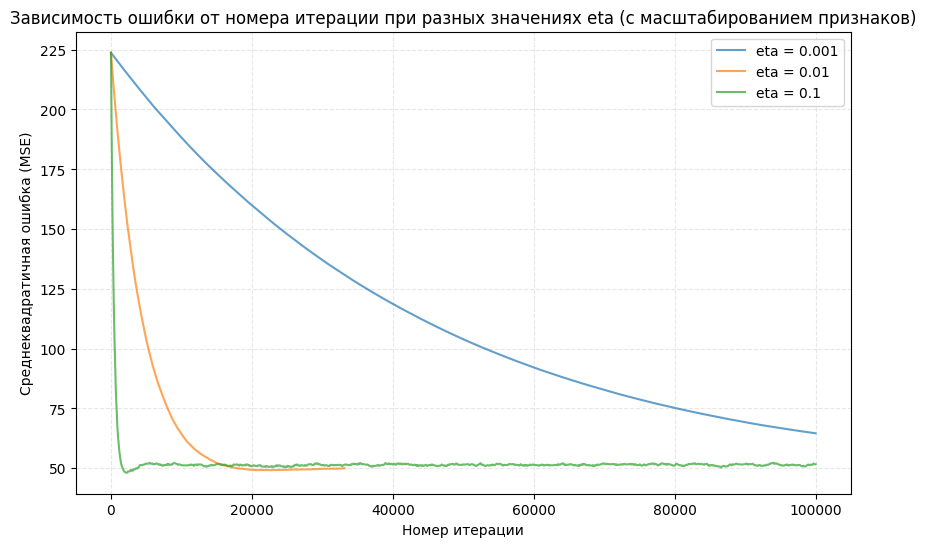

In [68]:
# ваш код
import matplotlib.pyplot as plt

max_iter = 10**5
tol = 1e-8

w_init = np.zeros(X_scaled.shape[1])  

etas = [0.001, 0.01, 0.1]
results = {}

for eta in etas:
    print(f"Запуск SGD с eta={eta}...")
    w_final, errors = stochastic_gradient_descent(X_scaled, y, w_init, eta, max_iter, tol)
    results[eta] = (w_final, errors)
    print(f"Итоговые веса (первые 5): {w_final[:5]}")

# Построение графика
plt.figure(figsize=(10, 6))

for eta, (_, errors) in results.items():
    # Прореживание точек для читаемости графика
    step = max(1, len(errors) // 1000)
    plt.plot(range(1, len(errors) + 1)[::step], errors[::step], label=f'eta = {eta}', alpha=0.7)

plt.xlabel('Номер итерации')
plt.ylabel('Среднеквадратичная ошибка (MSE)')
plt.title('Зависимость ошибки от номера итерации при разных значениях eta (с масштабированием признаков)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

**Выведите вектор весов, к которому сошелся метод.**

In [69]:
# ваш код
for eta, (w_final, _) in results.items():
    print(f"Вектор весов при eta={eta}:")
    print(w_final)
    print()

Вектор весов при eta=0.001:
[8.86139415 0.         2.51484388 1.75922802 0.45398557]

Вектор весов при eta=0.01:
[13.50243162  0.          3.77140673  2.64654218  0.10790124]

Вектор весов при eta=0.1:
[13.9873804   0.          3.90851621  2.84247203 -0.01960044]



**Выведите среднеквадратичную ошибку на последней итерации.**

In [70]:
# ваш код
print("MSE на последней итерации для каждого eta:")
for eta, (_, errors) in results.items():
    final_mse = errors[-1]
    print(f"eta = {eta}: MSE = {final_mse:.6f}")

MSE на последней итерации для каждого eta:
eta = 0.001: MSE = 64.528314
eta = 0.01: MSE = 49.938007
eta = 0.1: MSE = 51.560542
